# SQL Database Agent @ `LangGraph`

## Creating & Populating Database

In [85]:
import sqlite3

In [86]:
# Connect to SQLite database

connection = sqlite3.connect('mydb.db')

In [87]:
connection

In [88]:
# Creating table(s)

table_create_query_1 = """
CREATE TABLE IF NOT EXISTS employees (
    emp_id INTEGER PRIMARY KEY,
    first_name TEXT NOT NULL,
    last_name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    prhire_date TEXT NOT NULL,
    salary INTEGER NOT NULL
);
"""

In [89]:
table_create_query_2 = """
CREATE TABLE IF NOT EXISTS customers (
  customer_id INTEGER PRIMARY KEY AUTOINCREMENT,
  first_name TEXT NOT NULL,
  last_name TEXT NOT NULL,
  email TEXT UNIQUE NOT NULL,
  phone TEXT
);
"""

In [90]:
table_create_query_3 = """
CREATE TABLE IF NOT EXISTS orders (
    order_id INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_id INTEGER NOT NULL,
    order_date TEXT NOT NULL,
    amount REAL NOT NULL,
    FOREIGN KEY (customer_id) REFERENCES customers (customer_id)
);"""

In [91]:
# Creating cursor object

cursor = connection.cursor()

In [92]:
# Passing table creation queries to the database

cursor.execute(table_create_query_1)
cursor.execute(table_create_query_2)
cursor.execute(table_create_query_3)

In [93]:
# Dummy Data for Employees
employees_data = [
    (1, 'Alice', 'Johnson', 'alice.j@example.com', '2023-01-15', 75000),
    (2, 'Bob', 'Smith', 'bob.s@example.com', '2023-03-20', 68000),
    (3, 'Charlie', 'Davis', 'charlie.d@example.com', '2022-11-05', 82000),
    (4, 'Diana', 'Prince', 'diana.p@example.com', '2024-02-10', 95000),
    (5, 'Edward', 'Norton', 'edward.n@example.com', '2023-06-30', 70000)
]

# Dummy Data for Customers
customers_data = [
    ('John', 'Doe', 'john.doe@email.com', '555-0101'),
    ('Jane', 'Smith', 'jane.smith@email.com', '555-0102'),
    ('Michael', 'Brown', 'michael.b@email.com', '555-0103'),
    ('Emily', 'Davis', 'emily.d@email.com', '555-0104'),
    ('Chris', 'Wilson', 'chris.w@email.com', '555-0105')
]

# Dummy Data for Orders
import datetime
orders_data = [
    (1, datetime.date(2024, 1, 10).isoformat(), 150.50),
    (2, datetime.date(2024, 1, 12).isoformat(), 200.00),
    (1, datetime.date(2024, 2, 5).isoformat(), 45.75),
    (3, datetime.date(2024, 2, 14).isoformat(), 320.00),
    (4, datetime.date(2024, 3, 1).isoformat(), 12.99),
    (5, datetime.date(2024, 3, 5).isoformat(), 89.50),
    (2, datetime.date(2024, 3, 10).isoformat(), 110.25),
    (3, datetime.date(2024, 3, 15).isoformat(), 55.00),
    (1, datetime.date(2024, 3, 20).isoformat(), 250.00),
    (4, datetime.date(2024, 3, 22).isoformat(), 75.60)
]

cursor = connection.cursor()

# Insert Employees
cursor.executemany("INSERT OR IGNORE INTO employees (emp_id, first_name, last_name, email, prhire_date, salary) VALUES (?, ?, ?, ?, ?, ?)", employees_data)

# Insert Customers (using NULL for auto-increment ID)
cursor.executemany("INSERT OR IGNORE INTO customers (first_name, last_name, email, phone) VALUES (?, ?, ?, ?)", customers_data)

# Insert Orders
cursor.executemany("INSERT OR IGNORE INTO orders (customer_id, order_date, amount) VALUES (?, ?, ?)", orders_data)

connection.commit()
print("Dummy data populated successfully!")


Dummy data populated successfully!


In [94]:
# Retrieving data from table "orders"
cursor.execute("SELECT * FROM orders;")

In [95]:
for i in cursor.fetchall(): # Rows from table "orders"
    print(i)

(1, 1, '2024-01-10', 150.5)
(2, 2, '2024-01-12', 200.0)
(3, 1, '2024-02-05', 45.75)
(4, 3, '2024-02-14', 320.0)
(5, 4, '2024-03-01', 12.99)
(6, 5, '2024-03-05', 89.5)
(7, 2, '2024-03-10', 110.25)
(8, 3, '2024-03-15', 55.0)
(9, 1, '2024-03-20', 250.0)
(10, 4, '2024-03-22', 75.6)
(11, 1, '2024-01-10', 150.5)
(12, 2, '2024-01-12', 200.0)
(13, 1, '2024-02-05', 45.75)
(14, 3, '2024-02-14', 320.0)
(15, 4, '2024-03-01', 12.99)
(16, 5, '2024-03-05', 89.5)
(17, 2, '2024-03-10', 110.25)
(18, 3, '2024-03-15', 55.0)
(19, 1, '2024-03-20', 250.0)
(20, 4, '2024-03-22', 75.6)
(21, 1, '2024-01-10', 150.5)
(22, 2, '2024-01-12', 200.0)
(23, 1, '2024-02-05', 45.75)
(24, 3, '2024-02-14', 320.0)
(25, 4, '2024-03-01', 12.99)
(26, 5, '2024-03-05', 89.5)
(27, 2, '2024-03-10', 110.25)
(28, 3, '2024-03-15', 55.0)
(29, 1, '2024-03-20', 250.0)
(30, 4, '2024-03-22', 75.6)
(31, 1, '2024-01-10', 150.5)
(32, 2, '2024-01-12', 200.0)
(33, 1, '2024-02-05', 45.75)
(34, 3, '2024-02-14', 320.0)
(35, 4, '2024-03-01', 12.99)


<br>
<br>

# Creating Tools

In [96]:
from langchain_community.utilities import SQLDatabase

In [97]:
db = SQLDatabase.from_uri("sqlite:///mydb.db") # SQLite database

In [98]:
db

In [99]:
db.dialect # Version of SQL

'sqlite'

In [100]:
db.get_usable_table_names() # List of the tables created

['customers', 'employees', 'orders']

In [101]:
from langchain_groq import ChatGroq

# Load environment variables
from dotenv import load_dotenv
load_dotenv()

# NOTE: disable_tool_validation prevents Groq from erroring when the model hallucinates a tool name
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0, disable_tool_validation=True)

/Users/soubhiksinha/GitHub/SQL-Agent-LangGraph/venv/lib/python3.12/site-packages/pydantic/main.py:250: UserWarning: WARNING! disable_tool_validation is not default parameter.
                    disable_tool_validation was transferred to model_kwargs.
                    Please confirm that disable_tool_validation is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [102]:
llm.invoke("Hello, how are you?") # Invoking the LLM

AIMessage(content="I'm functioning properly, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here to help answer any questions or provide information you might need. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 41, 'total_tokens': 94, 'completion_time': 0.07108751, 'completion_tokens_details': None, 'prompt_time': 0.004736479, 'prompt_tokens_details': None, 'queue_time': 0.09322724, 'total_time': 0.075823989}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d317489708', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbfd0-2672-7303-822c-7298033f532e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 53, 'total_tokens': 94})

In [103]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

In [104]:
# Creating the toolkit for all the available tools

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

In [105]:
toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x1260a5820>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x1260a5820>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x1260a5820>),
 QuerySQLCheckerTool(description='Use this tool to double check if your 

In [106]:
tools = toolkit.get_tools()

In [107]:
for tool in tools:
  print(tool.name)

sql_db_query
sql_db_schema
sql_db_list_tables
sql_db_query_checker


In [108]:
list_tables_tool = next((tool for tool in tools if tool.name == "sql_db_list_tables"), None)

In [109]:
list_tables_tool

ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x1260a5820>)

In [110]:
# Fetching table schema tool

get_schema_tool = next((tool for tool in tools if tool.name == "sql_db_schema"), None)

In [111]:
get_schema_tool

InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x1260a5820>)

In [112]:
list_tables_tool.invoke("")

'customers, employees, orders'

In [113]:
print(get_schema_tool.invoke("customers")) # Getting the schema of the table "custoers" + first few rows


CREATE TABLE customers (
	customer_id INTEGER, 
	first_name TEXT NOT NULL, 
	last_name TEXT NOT NULL, 
	email TEXT NOT NULL, 
	phone TEXT, 
	PRIMARY KEY (customer_id), 
	UNIQUE (email)
)

/*
3 rows from customers table:
customer_id	first_name	last_name	email	phone
1	John	Doe	john.doe@email.com	555-0101
2	Jane	Smith	jane.smith@email.com	555-0102
3	Michael	Brown	michael.b@email.com	555-0103
*/


In [114]:
# Function for running query

from langchain_core.tools import tool
@tool
def db_query_tool(query: str) -> str:
  """
  Execute a SQL query against the database and return the result.
  If the query is invalid or returns no result, an error message will be returned.
  In case of an error, the user is advised to rewrite the query and try again.
  """
  result = db.run_no_throw(query)
  if not result:
    return "Error : Query Failed ! Please re-write your query and try again."
  return result

# Alias tool name: models often call `sql_query` by default
# @tool(name="sql_query")
# def sql_query(query: str) -> str:
#   return db_query_tool(query)

In [115]:
db_query_tool.invoke("SELECT * FROM employees;")

"[(1, 'Alice', 'Johnson', 'alice.j@example.com', '2023-01-15', 75000), (2, 'Bob', 'Smith', 'bob.s@example.com', '2023-03-20', 68000), (3, 'Charlie', 'Davis', 'charlie.d@example.com', '2022-11-05', 82000), (4, 'Diana', 'Prince', 'diana.p@example.com', '2024-02-10', 95000), (5, 'Edward', 'Norton', 'edward.n@example.com', '2023-06-30', 70000)]"

In [116]:
db.run("SELECT * FROM employees;")

"[(1, 'Alice', 'Johnson', 'alice.j@example.com', '2023-01-15', 75000), (2, 'Bob', 'Smith', 'bob.s@example.com', '2023-03-20', 68000), (3, 'Charlie', 'Davis', 'charlie.d@example.com', '2022-11-05', 82000), (4, 'Diana', 'Prince', 'diana.p@example.com', '2024-02-10', 95000), (5, 'Edward', 'Norton', 'edward.n@example.com', '2023-06-30', 70000)]"

<br>
<br>

## `query_check`

In [117]:
from typing import Annotated, Literal
from langchain_core.messages import AIMessage
# from langchain_core.pydantic_v1 import BaseModel, Field
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import AnyMessage, add_messages
from typing import Any
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks
from langgraph.prebuilt import ToolNode

In [118]:
from langchain_core.prompts import ChatPromptTemplate

query_check_system = """You are a SQL expert with a strong attention to detail.
Double check the SQLite query for common mistakes, including:
  - Using NOT IN with NULL values
  - Using UNION when UNION ALL should have been used
  - Using BETWEEN for exclusive ranges
  - Data type mismatch in predicates
  - Properly quoting identifiers
  - Using the correct number of arguments for functions
  - Casting to the correct data type  
  - Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes, just reproduce the original query.

You will call the appropriate tool to execute the query after running this check."""

query_check_prompt = ChatPromptTemplate.from_messages ([("system", query_check_system), ("placeholder", "{messages}")])

query_check = query_check_prompt | llm.bind_tools ([db_query_tool])

query_check.invoke({"messages": [("user", "SELECT * FROM employees LIMIT 5;")]})

AIMessage(content='SELECT * FROM employees LIMIT 5;\n\n', additional_kwargs={'tool_calls': [{'id': 'af179tex1', 'function': {'arguments': '{"query":"SELECT * FROM employees LIMIT 5;"}', 'name': 'db_query_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 440, 'total_tokens': 469, 'completion_time': 0.043349095, 'completion_tokens_details': None, 'prompt_time': 0.060903766, 'prompt_tokens_details': None, 'queue_time': 0.078917747, 'total_time': 0.104252861}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d317489708', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbfd0-27be-71e0-a55e-ae64249e9291-0', tool_calls=[{'name': 'db_query_tool', 'args': {'query': 'SELECT * FROM employees LIMIT 5;'}, 'id': 'af179tex1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 440, 'output_tokens': 29, 'total_tokens': 469})

In [119]:
query_check.invoke({"messages" : [("user", "SELECT * FROM employees LIMIT 5;")]})

AIMessage(content='SELECT * FROM employees LIMIT 5;\n\n', additional_kwargs={'tool_calls': [{'id': 'fpm868dr6', 'function': {'arguments': '{"query":"SELECT * FROM employees LIMIT 5;"}', 'name': 'db_query_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 440, 'total_tokens': 469, 'completion_time': 0.042374305, 'completion_tokens_details': None, 'prompt_time': 0.089853376, 'prompt_tokens_details': None, 'queue_time': 0.079477314, 'total_time': 0.132227681}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbfd0-2898-7d60-8d2d-0b4473a5470d-0', tool_calls=[{'name': 'db_query_tool', 'args': {'query': 'SELECT * FROM employees LIMIT 5;'}, 'id': 'fpm868dr6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 440, 'output_tokens': 29, 'total_tokens': 469})

<br>
<br>

## `query_gen`

In [120]:
class SubmitFinalAnswer(BaseModel):
  """Submit the final answer to the user based on the query results."""
  final_answer: str = Field(..., description="The final answer to the user based on the query results.")

# Add a note for a model to the generate a query based on the user's question and schema
query_gen_note = """You are a SQL expert with a strong attention to detail.
Given an input question, output a syntactically correct SQLite query to run, then look at the results of the query and return the answer.

DO NOT call any tool besides Submit FinalAnswer to submit the final answer.

When generating the query:

Output the SQL query that answers the input question without a tool call.

Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most 5 results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.

If you get an error while executing a query, rewrite the query and try again.

If you get an empty result set, you should try to rewrite the query to get a non-empty result set.
NEVER make stuff up if you don't have enough information to answer the query... just say you don't have enough information.

If you have enough information to answer the input question, simply invoke the appropriate tool to submit the final answer to the user.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database. Do not return any sql query except answer."""


query_gen_prompt = ChatPromptTemplate.from_messages ([("system", query_gen_note), ("placeholder", "{messages}")])

query_gen = query_gen_prompt | llm.bind_tools ([SubmitFinalAnswer])

<br>
<br>

## Creating Agent

### Creating Methods

In [121]:
class State(TypedDict):
  messages: Annotated[list[AnyMessage], add_messages]

In [122]:
def first_tool_call(state: State):
  return {"messages": [AIMessage(content="", tool_calls=[{"name":"sql_db_list_tables", "args":{}, "id":"tool_abcd123"}])]}

In [123]:
# Error Handling Method

def handle_tool_error(state: State):
  error = state.get("error")
  tool_calls = state["messages"][-1].tool_calls
  return {
    "messages" : [
      ToolMessage(content=f"Error: {repr(error)}\n please fix your mistakes.", tool_call_id = tc["id"],)
      for tc in tool_calls
    ]
  }

In [124]:
# Method for every tool to be converted to a node (with fallbck method)

def create_tool_node_with_fallback(tools: list) -> RunnableWithFallbacks[Any, dict]:
  return ToolNode(tools).with_fallbacks([RunnableLambda(handle_tool_error)], exception_key="error")

In [125]:
def model_check_query(state: State):
  return {"messages": [query_check.invoke({"messages": [state["messages"][-1]]})]}

In [126]:
# Method for Query Generation

def query_gen_node(state: State):
  message = query_gen.invoke(state)

  # LLM's do Hallucinate and might call the wrong tool. It's our responsibility to catch them and return an error message.
  tool_messages = []

  # If the model produced tool calls, ensure we respond with ToolMessage(s) that include tool_call_id
  if getattr(message, "tool_calls", None):
    for tc in message.tool_calls:
      if tc.get("name") != "SubmitFinalAnswer":
        tool_messages.append(
          ToolMessage(
            content=(
              f"Error: Wrong tool was called: {tc.get('name')}. Please fix your mistake. "
              "Remember to only call SubmitFinalAnswer to submit the final answer. "
              "Generated queries should be outputted WITHOUT a tool call."
            ),
            tool_call_id=tc.get("id"),
          )
        )
  return {"messages": [message] + tool_messages}


In [127]:
# Whether the flow must continue as per the message received of tool call (may be the last message too)

def should_continue(state: State):
  messages = state["messages"]
  last_message = messages[-1]

  # If the model called a tool:
  # - END only when it called SubmitFinalAnswer
  # - Otherwise, loop back to query_gen (we attach an Error ToolMessage in query_gen_node)
  if getattr(last_message, "tool_calls", None):
    for tc in last_message.tool_calls:
      if tc.get("name") == "SubmitFinalAnswer":
        return END
    return "query_gen"

  # If we got an error message from a tool execution, loop back
  if getattr(last_message, "content", "") and last_message.content.startswith("Error:"):
    return "query_gen"

  return "correct_query"

<br>

### Creating Workflow

In [128]:
workflow = StateGraph(State)

In [129]:
from transformers.utils.hub import create_and_tag_model_card
# Adding nodes

workflow.add_node("first_tool_call", first_tool_call)
workflow.add_node("list_tables_tool", create_tool_node_with_fallback([list_tables_tool]))
workflow.add_node("get_schema_tool", create_tool_node_with_fallback([get_schema_tool]))

# LLM Call
model_get_schema = llm.bind_tools([get_schema_tool])

workflow.add_node("model_get_schema", lambda state: {"messages": [model_get_schema.invoke(state["messages"])],},)
workflow.add_node("query_gen", query_gen_node)
workflow.add_node("correct_query", model_check_query)
workflow.add_node("execute_query", create_tool_node_with_fallback([db_query_tool]))

In [130]:
# Creating Edges

workflow.add_edge(START, "first_tool_call")
workflow.add_edge("first_tool_call", "list_tables_tool")
workflow.add_edge("list_tables_tool", "model_get_schema")
workflow.add_edge("model_get_schema", "get_schema_tool")
workflow.add_edge("get_schema_tool", "query_gen")
workflow.add_conditional_edges("query_gen", should_continue)
workflow.add_edge("correct_query", "execute_query")
workflow.add_edge("execute_query", "query_gen")

In [131]:
# Compiliing the workflow

app = workflow.compile()

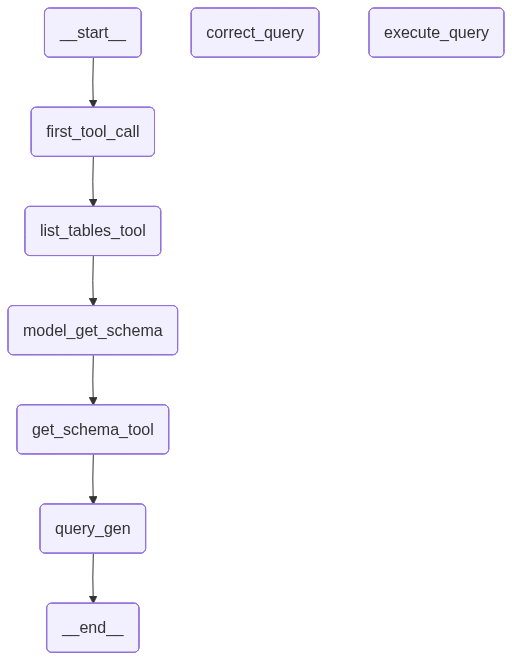

In [132]:
# Showing the graph

from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
  Image(
    app.get_graph().draw_mermaid_png(
      draw_method=MermaidDrawMethod.API
    )
  )
)

In [133]:
# Passing user query

query = {"messages" : [("user", "Tell me the name of the employee who'salary is more than 10000 ?")]}

In [134]:
response = app.invoke(query)

In [135]:
response["messages"][-1].tool_calls[0]["args"]["final_answer"]

'Alice, Bob, Charlie, Diana, Edward'